## 1. Import Library & Load Data <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Cấu hình đồ thị ──
plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# ── Load dữ liệu ──
df = pd.read_csv("kc_house_data.csv")

print(f"✅ Load successful!")
print(f"   Số dòng  : {df.shape[0]:,}")
print(f"   Số cột   : {df.shape[1]}")
print()
df.head()

✅ Load successful!
   Số dòng  : 21,613
   Số cột   : 21



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Preprocess (Data Cleaning) <a id='2'></a>




In [2]:
# ── 2.1 Import pipeline từ preprocess.py ──
import sys, os
sys.path.append(os.path.abspath('.'))

from preprocess import load_raw, clean, engineer_features, transform_target

print('✅ Import preprocess.py successful!')


✅ Import preprocess.py successful!


In [5]:
# ── 2.2 Load & Clean data ──

df_raw   = load_raw("kc_house_data.csv")      # load CSV raw
df_clean = clean(df_raw)            # delete outliers, debug

print(f'\n📦 Raw   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print(f'✅ Clean : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols')
df_clean.head()


[load]  Rows: 21,613  |  Columns: 21
[clean] Removed 109 extreme-price outliers  (cap: $2,453,325)
[clean] Remaining rows: 21,502

📦 Raw   : 21,613 rows × 21 cols
✅ Clean : 21,502 rows × 19 cols


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# ── 2.3 Feature Engineering ──
df = engineer_features(df_clean)    # tạo house_age, is_renovated, luxury_score, ...

#Recover year_sold / month_sold from the original date column (required for SQL & RQ3).
df['date']       = pd.to_datetime(df_raw.loc[df_clean.index, 'date'],
                                   format='%Y%m%dT%H%M%S', errors='coerce')
df['year_sold']  = df['date'].dt.year
df['month_sold'] = df['date'].dt.month

print(f'✅ after feature engineering: {df.shape[1]} features')
print('New columns:', [c for c in df.columns if c not in df_raw.columns])
df.head()


[engineer] Feature count: 27 features  (target excluded)
✅ after feature engineering: 31 features
New columns: ['house_age', 'years_since_reno', 'is_renovated', 'living_to_lot_ratio', 'above_to_living_ratio', 'basement_present', 'living_vs_neighbors', 'lot_vs_neighbors', 'luxury_score', 'bath_bed_ratio', 'total_rooms', 'year_sold', 'month_sold']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,above_to_living_ratio,basement_present,living_vs_neighbors,lot_vs_neighbors,luxury_score,bath_bed_ratio,total_rooms,date,year_sold,month_sold
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.999153,0,-160,0,3.4,0.250000,4.0,2014-10-13,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.844030,1,880,-397,3.4,0.562500,6.0,2014-12-09,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.998703,0,-1950,1938,3.0,0.333333,3.0,2015-02-25,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.535441,1,600,0,3.8,0.600000,7.0,2014-12-09,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.999405,0,-120,577,3.8,0.500000,5.0,2015-02-18,2015,2


In [6]:
# ── 2.4 Descriptive statistics ──
cols_key = ['price', 'bedrooms', 'bathrooms', 'sqft_living',
            'grade', 'condition', 'house_age', 'is_renovated', 'luxury_score']
df[cols_key].describe().round(2)


,price,bedrooms,bathrooms,sqft_living,grade,condition,house_age,is_renovated,luxury_score
count,21502.00,21502.00,21502.00,21502.00,21502.00,21502.00,21502.00,21502.00,21502.00
mean,526575.53,3.36,2.10,2062.46,7.64,3.41,55.00,0.04,3.78
std,308043.00,0.90,0.76,880.31,1.15,0.65,29.35,0.20,0.52
min,75000.00,0.00,0.00,290.00,1.00,1.00,11.00,0.00,0.60
25%,320000.00,3.00,1.50,1420.00,7.00,3.00,29.00,0.00,3.40
50%,450000.00,3.00,2.25,1910.00,7.00,3.00,51.00,0.00,3.80
75%,640000.00,4.00,2.50,2540.00,8.00,4.00,75.00,0.00,4.00
max,2450000.00,10.00,8.00,13540.00,13.00,5.00,126.00,1.00,6.60


## 3. SQL Analysis (SQL-in-Python with SQLite) <a id='3'></a>

> **How it works**: Load the DataFrame into an in-memory SQLite database → run pure SQL queries → return the results as a DataFrame.

In [ ]:
# ── Initialize an in-memory SQLite database ──
conn = sqlite3.connect(':memory:')
df.to_sql('houses', conn, index=False, if_exists='replace')
print("✅ Successfully loaded data into SQLite (in-memory database)")
print(f"   Table: 'houses'  |  {len(df):,} rows  |  {len(df.columns)} columns")

def sql(query):
    """Helper: run SQL and return DataFrame."""
    return pd.read_sql_query(query, conn)

✅ Đã nạp dữ liệu vào SQLite (in-memory database)
   Table: 'houses'  |  21,502 rows  |  31 columns


In [42]:
# 3.1 Top 10 zip codes with the highest average house prices
sql("""
    SELECT
        zipcode,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)       AS avg_price,
        ROUND(AVG(sqft_living), 0) AS avg_living_area,
        ROUND(AVG(grade), 2)       AS avg_quality
    FROM houses
    GROUP BY zipcode
    ORDER BY avg_price DESC
    LIMIT 10
""")

,zipcode,total_houses,avg_price,avg_living_area,avg_quality
0,98039,35,1589647.0,2978.0,8.77
1,98004,298,1223358.0,2737.0,8.52
2,98040,272,1112573.0,3016.0,8.89
3,98112,257,1016228.0,2380.0,8.35
4,98109,107,839056.0,1992.0,7.96
5,98006,491,829485.0,2841.0,8.76
6,98119,182,827491.0,1974.0,7.99
7,98102,103,819933.0,2019.0,8.19
8,98105,223,811045.0,2086.0,7.77
9,98005,168,810165.0,2657.0,8.49


In [43]:
# 3.2 Impact of waterfront on house prices
sql("""
    SELECT
        CASE waterfront
            WHEN 1 THEN 'Has waterfront view'
            ELSE 'No waterfront view'
        END                         AS house_type,
        COUNT(*)                    AS number_of_houses,
        ROUND(AVG(price), 0)       AS average_price,
        ROUND(MIN(price), 0)       AS minimum_price,
        ROUND(MAX(price), 0)       AS maximum_price
    FROM houses
    GROUP BY waterfront
""")

,house_type,number_of_houses,average_price,minimum_price,maximum_price
0,No waterfront view,21373,522470.0,75000.0,2450000.0
1,Has waterfront view,129,1206757.0,285000.0,2400000.0


In [44]:
# 3.3 Trend of selling prices by month
base = sql("""
    SELECT
        month_sold,
        COUNT(*)                AS number_of_transactions,
        ROUND(AVG(price), 0)   AS average_price
    FROM houses
    GROUP BY month_sold
    ORDER BY month_sold
""")

# Pandas: tính median
median = df.groupby('month_sold')['price'].median().reset_index()
median.columns = ['month_sold', 'average_price_median']
median['average_price_median'] = median['average_price_median'].round(0)

# Merge lại
monthly = base.merge(median, on='month_sold')
monthly

,month_sold,number_of_transactions,average_price,average_price_median
0,1,971,528167.0,455000.0
1,2,1242,525526.0,440000.0
2,3,1870,517146.0,450000.0
3,4,2217,521794.0,450000.0
4,5,2400,521295.0,442750.0
5,6,2167,534488.0,451300.0
6,7,2206,530513.0,450000.0
7,8,1927,530630.0,445000.0
8,9,1771,526011.0,450000.0
9,10,1862,522588.0,450000.0


In [45]:
# 3.4 Correlation between grade, condition, and price
sql("""
    SELECT
        grade,
        condition,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)       AS avg_price
    FROM houses
    WHERE grade BETWEEN 6 AND 10
    GROUP BY grade, condition
    ORDER BY grade, condition
""")

,grade,condition,total_houses,avg_price
0,6,1,11,303814.0
1,6,2,59,269484.0
2,6,3,1035,290652.0
3,6,4,685,318732.0
4,6,5,248,310141.0
5,7,1,6,334417.0
6,7,2,75,342699.0
7,7,3,5233,385641.0
8,7,4,2833,412923.0
9,7,5,832,479475.0


In [46]:
# ── 3.5 Price analysis by number of floors ──
print("=" * 50)
print("3.5 AVERAGE PRICE BY NUMBER OF FLOORS")
print("=" * 50)
sql("""
    SELECT
        floors,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)        AS avg_price,
        ROUND(MIN(price), 0)        AS min_price,
        ROUND(MAX(price), 0)        AS max_price,
        ROUND(AVG(sqft_living), 0)  AS avg_living_area
    FROM houses
    GROUP BY floors
    ORDER BY floors
""")

3.5 AVERAGE PRICE BY NUMBER OF FLOORS


,floors,total_houses,avg_price,min_price,max_price,avg_living_area
0,1.0,10659,437300.0,75000.0,2400000.0,1725.0
1,1.5,1906,554126.0,92000.0,2408000.0,1902.0
2,2.0,8169,626244.0,90000.0,2450000.0,2546.0
3,2.5,150,893919.0,255000.0,2350000.0,2915.0
4,3.0,611,574539.0,205000.0,2280000.0,1776.0
5,3.5,7,595214.0,435000.0,1095000.0,1776.0


In [47]:
# ── 3.6 Price analysis by basement condition ──
print("=" * 50)
print("3.6 AVERAGE PRICE BY BASEMENT CONDITION")
print("=" * 50)
sql("""
    SELECT
        CASE
            WHEN sqft_basement = 0    THEN '1. No basement'
            WHEN sqft_basement < 500  THEN '2. Small basement (<500 sqft)'
            WHEN sqft_basement < 1000 THEN '3. Medium basement (500-1000 sqft)'
            ELSE                           '4. Large basement (>1000 sqft)'
        END                         AS basement_condition,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)        AS avg_price,
        ROUND(MIN(price), 0)        AS min_price,
        ROUND(MAX(price), 0)        AS max_price
    FROM houses
    GROUP BY basement_condition
    ORDER BY basement_condition
""")

3.6 AVERAGE PRICE BY BASEMENT CONDITION


,basement_condition,total_houses,avg_price,min_price,max_price
0,1. No basement,13102,482220.0,75000.0,2450000.0
1,2. Small basement (<500 sqft),2453,487015.0,100000.0,2384000.0
2,3. Medium basement (500-1000 sqft),3998,571156.0,134000.0,2400000.0
3,4. Large basement (>1000 sqft),1949,783094.0,189950.0,2450000.0


In [48]:
# ── 3.7 Price analysis by number of bedrooms ──
print("=" * 50)
print("3.7 AVERAGE PRICE BY NUMBER OF BEDROOMS")
print("=" * 50)
sql("""
    SELECT
        bedrooms,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)        AS avg_price,
        ROUND(AVG(sqft_living), 0)  AS avg_living_area,
        ROUND(AVG(grade), 2)        AS avg_grade,
        ROUND(MIN(price), 0)        AS min_price,
        ROUND(MAX(price), 0)        AS max_price
    FROM houses
    WHERE bedrooms BETWEEN 1 AND 8
    GROUP BY bedrooms
    ORDER BY bedrooms
""")

3.7 AVERAGE PRICE BY NUMBER OF BEDROOMS


,bedrooms,total_houses,avg_price,avg_living_area,avg_grade,min_price,max_price
0,1,199,317643.0,885.0,6.10,75000.0,1247000.0
1,2,2759,400330.0,1238.0,6.87,78000.0,1998000.0
2,3,9812,463014.0,1802.0,7.47,82000.0,2400000.0
3,4,6836,620300.0,2538.0,8.10,100000.0,2450000.0
4,5,1561,720624.0,2973.0,8.20,133000.0,2450000.0
5,6,265,724817.0,3166.0,7.97,175000.0,2400000.0
6,7,36,835000.0,3874.0,8.33,280000.0,2450000.0
7,8,12,922167.0,3474.0,7.75,340000.0,2150000.0


In [ ]:
# ── 3.8 Rate of 
#  houses by area (Top 10) ──
print("=" * 50)
print("3.8 RATE OF RENOVATED HOUSES BY AREA (TOP 10)")
print("=" * 50)
sql("""
    SELECT
        zipcode,
        COUNT(*)                                         AS total_houses,
        SUM(is_renovated)                                AS renovated_houses,
        ROUND(SUM(is_renovated) * 100.0 / COUNT(*), 2)  AS renovation_rate,
        ROUND(AVG(CASE WHEN is_renovated = 1
                  THEN price END), 0)                    AS avg_price_renovated,
        ROUND(AVG(CASE WHEN is_renovated = 0
                  THEN price END), 0)                    AS avg_price_unrenovated
    FROM houses
    GROUP BY zipcode
    HAVING COUNT(*) >= 50
    ORDER BY renovation_rate DESC
    LIMIT 10
""")    

3.8 RATE OF RENOVATED HOUSES BY AREA (TOP 10)


,zipcode,total_houses,renovated_houses,renovation_rate,avg_price_renovated,avg_price_unrenovated
0,98040,272,31,11.40,1320837.0,1085784.0
1,98112,257,29,11.28,996479.0,1018740.0
2,98122,290,32,11.03,802893.0,613457.0
3,98010,100,11,11.00,399673.0,426631.0
4,98119,182,20,10.99,958874.0,811271.0
5,98166,253,25,9.88,568755.0,443798.0
6,98004,298,29,9.73,1423917.0,1201736.0
7,98116,330,32,9.70,744470.0,605122.0
8,98146,288,26,9.03,452993.0,350204.0
9,98024,81,7,8.64,451700.0,592713.0


In [50]:
# ── 3.9 Price analysis by view quality ──
print("=" * 50)
print("3.9 AVERAGE PRICE BY VIEW QUALITY")
print("=" * 50)
sql("""
    SELECT
        CASE view
            WHEN 0 THEN '0 - No view'
            WHEN 1 THEN '1 - Poor view'
            WHEN 2 THEN '2 - Average view'
            WHEN 3 THEN '3 - Good view'
            WHEN 4 THEN '4 - Excellent view'
        END                         AS view_quality,
        COUNT(*)                    AS total_houses,
        ROUND(AVG(price), 0)        AS avg_price,
        ROUND(MIN(price), 0)        AS min_price,
        ROUND(MAX(price), 0)        AS max_price,
        ROUND(AVG(sqft_living), 0)  AS avg_living_area
    FROM houses
    GROUP BY view
    ORDER BY view
""")

3.9 AVERAGE PRICE BY VIEW QUALITY


,view_quality,total_houses,avg_price,min_price,max_price,avg_living_area
0,0 - No view,19452,491992.0,75000.0,2450000.0,1991.0
1,1 - Poor view,326,771495.0,217000.0,2400000.0,2518.0
2,2 - Average view,948,755127.0,169317.0,2450000.0,2611.0
3,3 - Good view,500,925747.0,154000.0,2450000.0,2966.0
4,4 - Excellent view,276,1166540.0,252000.0,2400000.0,3034.0


## 4. Exploratory Analysis (EDA — Python) <a id='4'></a>

In [ ]:
# ── 4.1 Correlation coefficients of features with house prices ──
print("=" * 50)
print("4.1 CORRELATION COEFFICIENTS OF FEATURES WITH HOUSE PRICES")
print("=" * 50)

corr_cols = ['price', 'sqft_living', 'sqft_above', 'sqft_basement',
             'sqft_lot', 'grade', 'bathrooms', 'bedrooms',
             'floors', 'view', 'condition', 'house_age', 'years_since_reno', 'is_renovated', 
             'basement_present', 'luxury_score', 'bath_bed_ratio', 'total_rooms', 'zipcode']

corr_table = (
    df[corr_cols].corr()[['price']]
    .drop('price')
    .rename(columns={'price': 'correlation'})
    .sort_values('correlation', ascending=False)
    .round(4)
)
corr_table['strength'] = corr_table['correlation'].apply(
    lambda x: '🔴 Strong'       if abs(x) >= 0.5
         else '🟡 Moderate' if abs(x) >= 0.3
         else '⚪ Weak'
)
display(corr_table)
print("\n📌 sqft_living and luxury_score are the two most important features for the house price prediction model.")

4.1 CORRELATION COEFFICIENTS OF FEATURES WITH HOUSE PRICES


,correlation,strength
luxury_score,0.7254,🔴 Strong
sqft_living,0.6854,🔴 Strong
grade,0.6808,🔴 Strong
sqft_above,0.5917,🔴 Strong
bathrooms,0.5134,🔴 Strong
total_rooms,0.4686,🟡 Moderate
view,0.3683,🟡 Moderate
bath_bed_ratio,0.3572,🟡 Moderate
bedrooms,0.3223,🟡 Moderate
sqft_basement,0.2935,⚪ Weak



📌 sqft_living and luxury_score are the two most important features for the house price prediction model.


In [53]:
# ── 4.2 Price distribution — Skewness & Log Transform ──
print("=" * 50)
print("4.2 PRICE DISTRIBUTION — SKEWNESS & LOG TRANSFORM")
print("=" * 50)

stats_origin = pd.Series({
    'mean'    : round(df['price'].mean(), 0),
    'median'  : round(df['price'].median(), 0),
    'std'     : round(df['price'].std(), 0),
    'skewness': round(df['price'].skew(), 4),
    'kurtosis': round(df['price'].kurt(), 4),
}, name='price_raw')

log_price = np.log1p(df['price'])
stats_log = pd.Series({
    'mean'    : round(log_price.mean(), 4),
    'median'  : round(log_price.median(), 4),
    'std'     : round(log_price.std(), 4),
    'skewness': round(log_price.skew(), 4),
    'kurtosis': round(log_price.kurt(), 4),
}, name='log_price')

display(pd.concat([stats_origin, stats_log], axis=1))
print("\n📌 Skewness raw > 0.75 → recommended to use log(price) as the target when training the model.")
print(f"   Skewness after    log transform: {log_price.skew():.4f} ≈ 0 → More normally distributed")

4.2 PRICE DISTRIBUTION — SKEWNESS & LOG TRANSFORM


,price_raw,log_price
mean,526576.0000,13.0382
median,450000.0000,13.0170
std,308043.0000,0.5100
skewness,2.1157,0.2554
kurtosis,6.5721,0.1567



📌 Skewness raw > 0.75 → recommended to use log(price) as the target when training the model.
   Skewness after    log transform: 0.2554 ≈ 0 → More normally distributed


In [54]:
# ── 4.3 Outlier detection using IQR method ──
print("=" * 50)
print("4.3 OUTLIER DETECTION USING IQR METHOD")
print("=" * 50)

num_cols = ['price', 'sqft_living', 'sqft_lot', 'sqft_above',
            'sqft_basement', 'house_age', 'grade', 'bedrooms', 'bathrooms']

outlier_summary = []
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'feature'     : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'lower_bound' : round(lower, 2),
        'upper_bound' : round(upper, 2),
        'num_outliers'  : n_out,
        'percentage_%' : round(n_out / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('num_outliers', ascending=False)
display(outlier_df)
print("\n📌 Columns with high outliers need to be processed before training (winsorization or log transformation)")

4.3 OUTLIER DETECTION USING IQR METHOD


,feature,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,percentage_%
2,sqft_lot,5040.0,10589.5,5549.5,-3284.25,18913.75,2405,11.19
6,grade,7.0,8.0,1.0,5.50,9.50,1807,8.40
0,price,320000.0,640000.0,320000.0,-160000.00,1120000.00,1052,4.89
3,sqft_above,1190.0,2200.0,1010.0,-325.00,3715.00,572,2.66
7,bedrooms,3.0,4.0,1.0,1.50,5.50,534,2.48
4,sqft_basement,0.0,550.0,550.0,-825.00,1375.00,530,2.46
1,sqft_living,1420.0,2540.0,1120.0,-260.00,4220.00,493,2.29
8,bathrooms,1.5,2.5,1.0,0.00,4.00,220,1.02
5,house_age,29.0,75.0,46.0,-40.00,144.00,0,0.00



📌 Columns with high outliers need to be processed before training (winsorization or log transformation)


In [57]:
# ── 4.4 Price statistics by area groups ──
print("=" * 50)
print("4.4 PRICE STATISTICS BY AREA GROUPS (SQFT_LIVING)")
print("=" * 50)

bins_sqft   = [0, 1000, 2000, 3000, 4000, float('inf')]
labels_sqft = ['<1000', '1000-2000', '2000-3000', '3000-4000', '>4000']
df['area_group'] = pd.cut(df['sqft_living'], bins=bins_sqft, labels=labels_sqft)

sqft_table = (
    df.groupby('area_group', observed=True)['price']
    .agg(
        total_houses ='count',
        avg_price    =lambda x: round(x.mean(), 0),
        median_price =lambda x: round(x.median(), 0),
        min_price    =lambda x: round(x.min(), 0),
        max_price    =lambda x: round(x.max(), 0),
    )
    .reset_index()
)
display(sqft_table)
print(f"\n📌 Difference in average price between >4000 and <1000 area groups: "
      f"${sqft_table.iloc[-1]['avg_price'] - sqft_table.iloc[0]['avg_price']:,.0f}")

4.4 PRICE STATISTICS BY AREA GROUPS (SQFT_LIVING)


,area_group,total_houses,avg_price,median_price,min_price,max_price
0,<1000,1494,298301.0,285000.0,75000.0,747000.0
1,1000-2000,10217,398779.0,375000.0,95000.0,1500000.0
2,2000-3000,6818,579320.0,542975.0,194250.0,2400000.0
3,3000-4000,2285,861614.0,797500.0,274975.0,2400000.0
4,>4000,688,1284658.0,1200000.0,404000.0,2450000.0



📌 Difference in average price between >4000 and <1000 area groups: $986,357


In [ ]:
# ── 4.5    Price statistics by renovation status and house age group     ──
print("=" * 50)
print("4.5PRICE BY RENOVATION STATUS & HOUSE AGE GROUP")
print("=" * 50)

# Nhóm house_age
bins_age   = [0, 10, 20, 40, 60, float('inf')]
labels_age = ['<10 yrs', '10-20 yrs', '20-40 yrs', '40-60 yrs', '>60 yrs']
df['age_group'] = pd.cut(df['house_age'], bins=bins_age, labels=labels_age)

reno_age_table = (
    df.groupby(['age_group', 'is_renovated'], observed=True)['price']
    .agg(
        total_houses='count',
        avg_price   =lambda x: round(x.mean(), 0),
        median_price=lambda x: round(x.median(), 0),
    )
    .reset_index()
)
reno_age_table['is_renovated'] = reno_age_table['is_renovated'].map(
    {0: 'Not renovated', 1: 'Renovated'}
)
display(reno_age_table)
print("\n📌 Old houses (>60 yrs) that were renovated — do they recover price vs non-renovated?")


4.5PRICE BY RENOVATION STATUS & HOUSE AGE GROUP


,age_group,is_renovated,total_houses,avg_price,median_price
0,10-20 yrs,Not renovated,2690,603396.0,500000.0
1,20-40 yrs,Not renovated,5304,566125.0,487550.0
2,20-40 yrs,Renovated,15,855187.0,550000.0
3,40-60 yrs,Not renovated,4640,473691.0,418650.0
4,40-60 yrs,Renovated,109,768520.0,599000.0
5,>60 yrs,Not renovated,7972,484724.0,425000.0
6,>60 yrs,Renovated,772,696666.0,595500.0



📌 Old houses (>60 yrs) that were renovated — do they recover price vs non-renovated?


## 5. Visualizations by Research Questions <a id='5'></a>

Each group of charts is designed to directly answer a Research Question.

### 📌 RQ1 — Which physical factors have the strongest impact on house prices?
> `sqft_living`, `bedrooms`, `floors` vs `price`


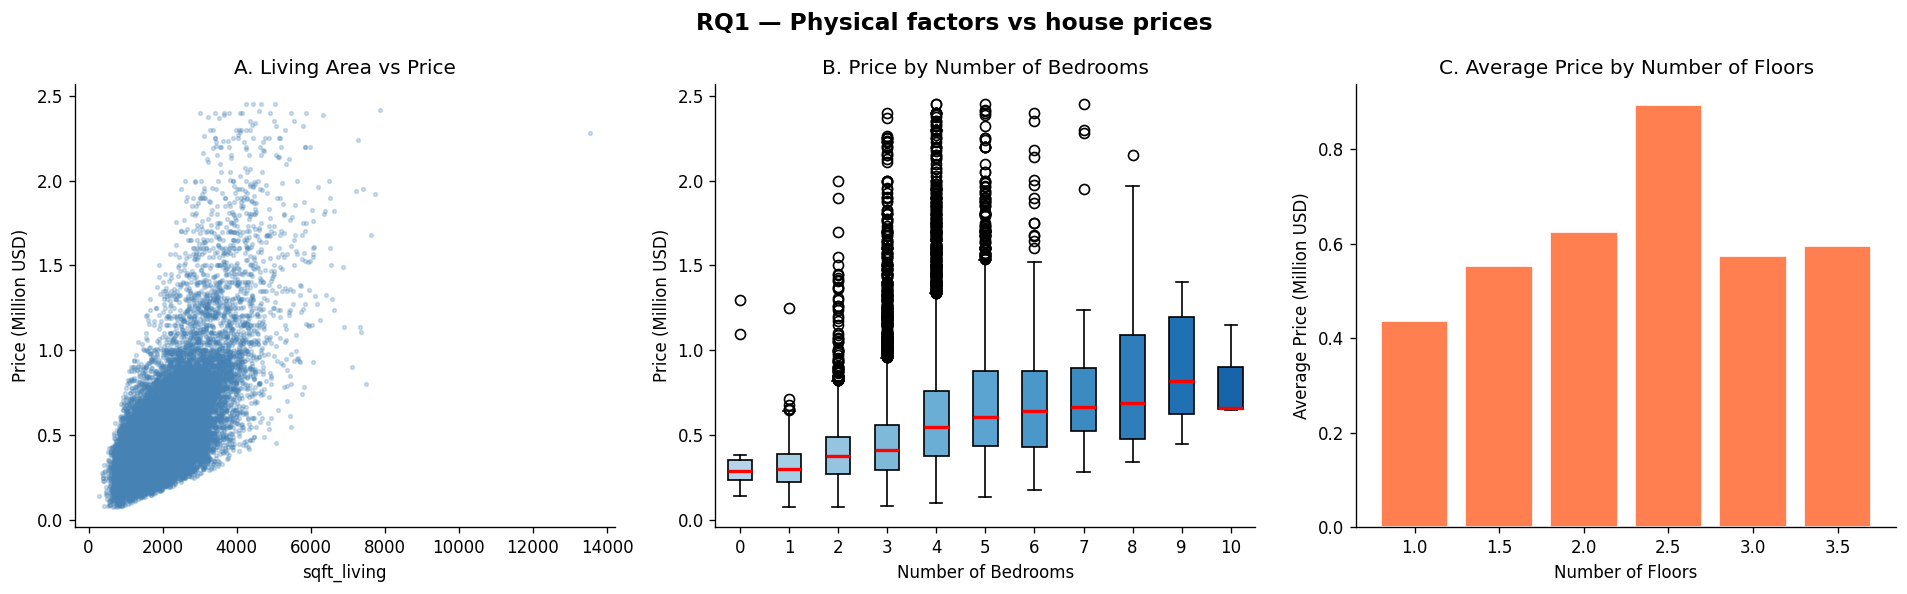

📌 sqft_living has the highest correlation with price among the physical features


In [59]:
# RQ1: Physical features vs price
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ1 — Physical factors vs house prices', fontsize=14, fontweight='bold')

# A) sqft_living scatter
ax = axes[0]
ax.scatter(df['sqft_living'], df['price']/1e6, alpha=0.25, s=5, color='steelblue')
ax.set_title('A. Living Area vs Price')
ax.set_xlabel('sqft_living')
ax.set_ylabel('Price (Million USD)')

# B) boxplot price by number of bedrooms
ax = axes[1]
beds = sorted(df['bedrooms'].unique())
data_by_bed = [df[df['bedrooms']==b]['price'].values/1e6 for b in beds]
bp = ax.boxplot(data_by_bed, labels=beds, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(beds)))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
ax.set_title('B. Price by Number of Bedrooms')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Price (Million USD)')

# C) bar average price by number of floors
ax = axes[2]
floor_price = df.groupby('floors')['price'].mean() / 1e6
ax.bar(floor_price.index.astype(str), floor_price.values, color='coral', edgecolor='white')
ax.set_title('C. Average Price by Number of Floors')
ax.set_xlabel('Number of Floors')
ax.set_ylabel('Average Price (Million USD)')

plt.tight_layout()
plt.savefig('rq1_physical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 sqft_living has the highest correlation with price among the physical features')


### 📌 RQ2 — Meaning of location factors and property characteristics?
> `zipcode`, `waterfront`, `view` vs `price`


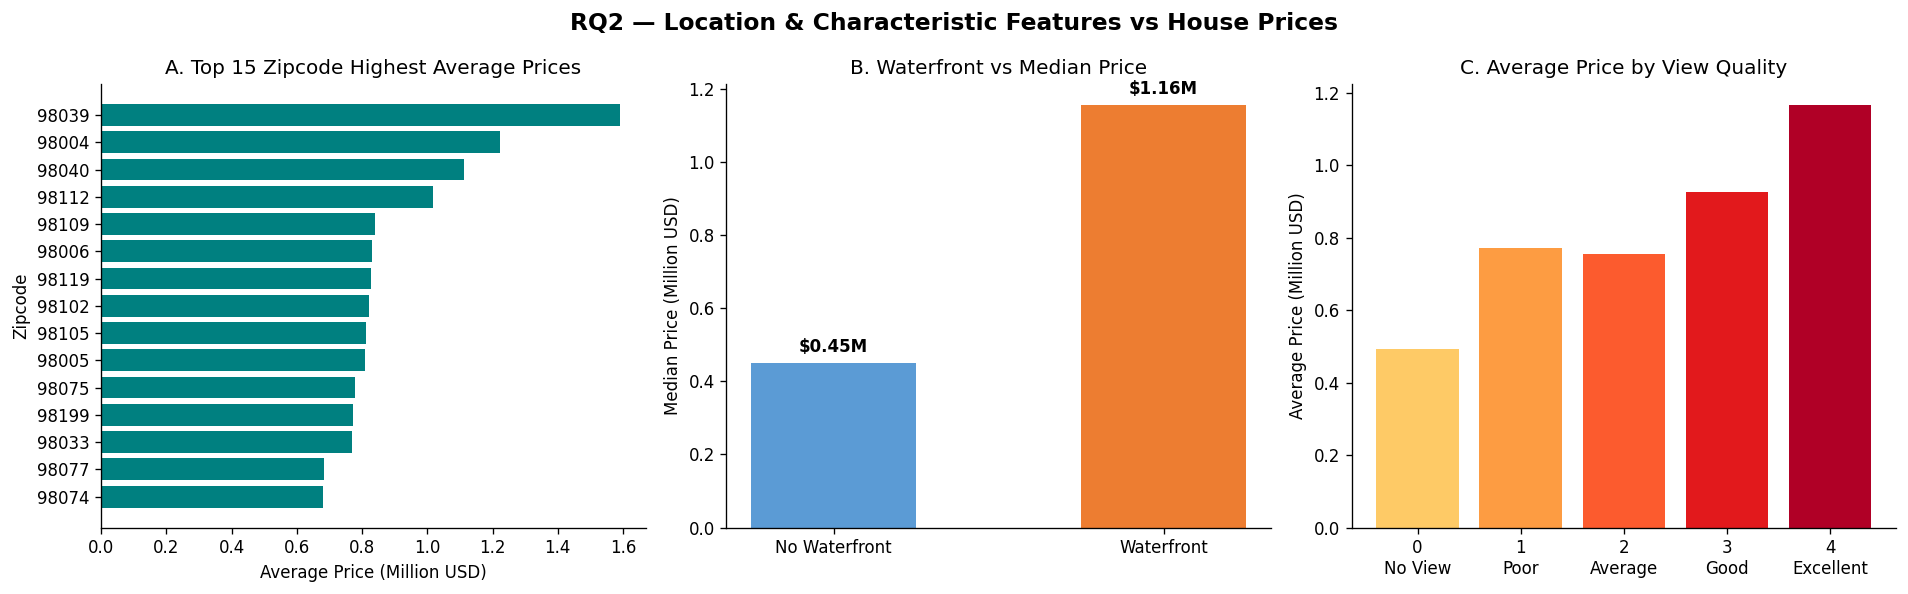

📌 Waterfront increases price ~2x; Excellent view (4) significantly increases price


In [60]:
# RQ2: Location & characteristic features vs price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ2 — Location & Characteristic Features vs House Prices', fontsize=14, fontweight='bold')

# A) Top 15 zipcode giá TB cao nhất
ax = axes[0]
zip_price = df.groupby('zipcode')['price'].mean().nlargest(15) / 1e6
ax.barh(zip_price.index.astype(str), zip_price.values, color='teal')
ax.set_title('A. Top 15 Zipcode Highest Average Prices')
ax.set_xlabel('Average Price (Million USD)')
ax.set_ylabel('Zipcode')
ax.invert_yaxis()

# B) Waterfront vs không waterfront
ax = axes[1]
wf_labels = ['No Waterfront', 'Waterfront']
wf_prices = [df[df['waterfront']==v]['price'].median()/1e6 for v in [0,1]]
bars = ax.bar(wf_labels, wf_prices, color=['#5B9BD5','#ED7D31'], width=0.5)
for bar, val in zip(bars, wf_prices):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.02, f'${val:.2f}M',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('B. Waterfront vs Median Price')
ax.set_ylabel('Median Price (Million USD)')

# C) Average Price by View Rating (0–4)
ax = axes[2]
view_price = df.groupby('view')['price'].mean() / 1e6
view_labels = ['0\nNo View','1\nPoor','2\nAverage','3\nGood','4\nExcellent']
ax.bar(view_labels[:len(view_price)], view_price.values,
       color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(view_price))))
ax.set_title('C. Average Price by View Quality')
ax.set_ylabel('Average Price (Million USD)')

plt.tight_layout()
plt.savefig('rq2_location_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Waterfront increases price ~2x; Excellent view (4) significantly increases price')


### 📌 RQ3 — How house prices change over time

> By month (month_sold) and year (year_sold)


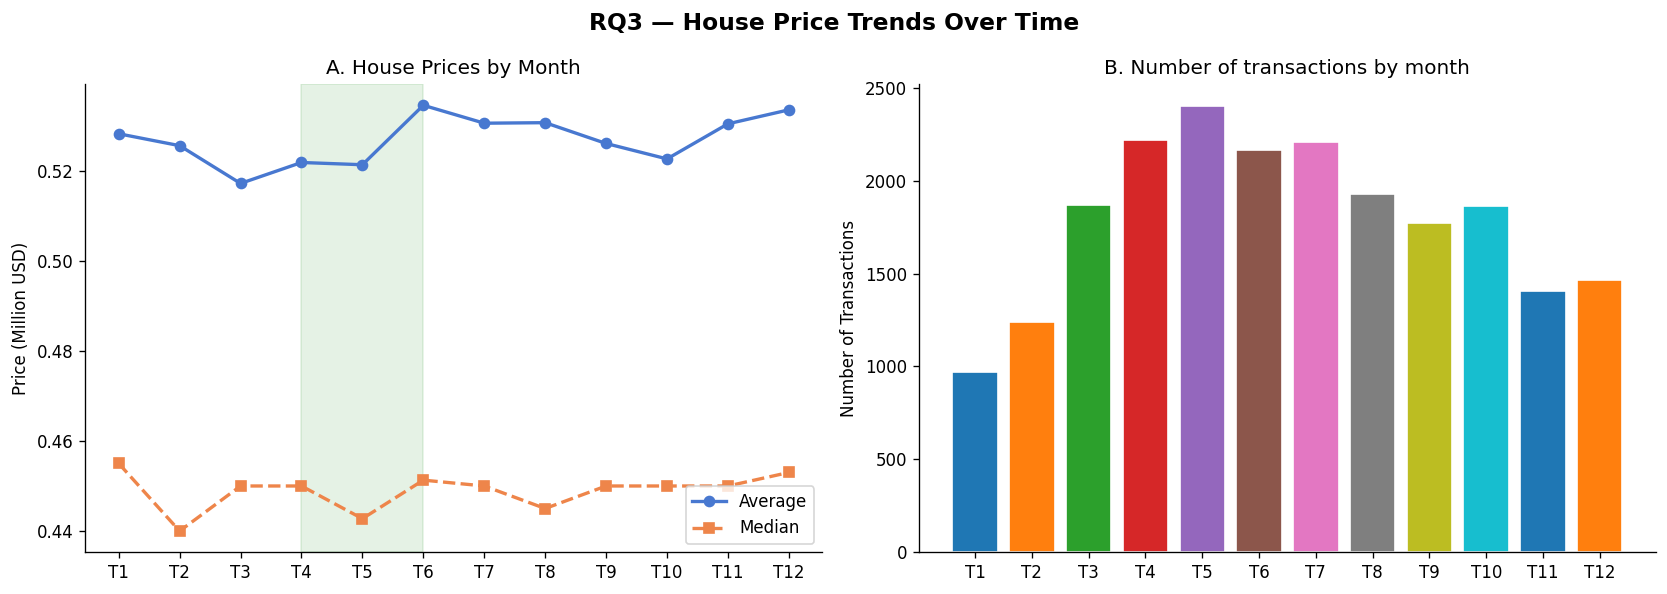

📌 Months 4–6 have the highest prices and transaction volumes (spring — peak season)


In [ ]:
# RQ3: Price trend over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RQ3 — House Price Trends Over Time', fontsize=14, fontweight='bold')

# A) Average and median price by month
ax = axes[0]
monthly_mean   = df.groupby('month_sold')['price'].mean()   / 1e6
monthly_median = df.groupby('month_sold')['price'].median() / 1e6
month_names = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
ax.plot(monthly_mean.index,   monthly_mean.values,   marker='o', label='Average', linewidth=2)
ax.plot(monthly_median.index, monthly_median.values, marker='s', label='Median',   linewidth=2, linestyle='--')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_title('A. House Prices by Month')
ax.set_ylabel('Price (Million USD)')
ax.legend()
ax.axvspan(4, 6, alpha=0.1, color='green', label='Peak season')

# B) Number of transactions by month (volume)
ax = axes[1]
monthly_count = df.groupby('month_sold').size()
ax.bar(monthly_count.index, monthly_count.values,
       color=plt.cm.tab10.colors[:12], edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_title('B. Number of transactions by month')
ax.set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('rq3_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Months 4–6 have the highest prices and transaction volumes (spring — peak season)')


### 📌 RQ4 — Does home renovation really increase property value? Does it depend on location?

> Comparing prices of renovated homes (is_renovated = 1) vs non-renovated homes by zipcode


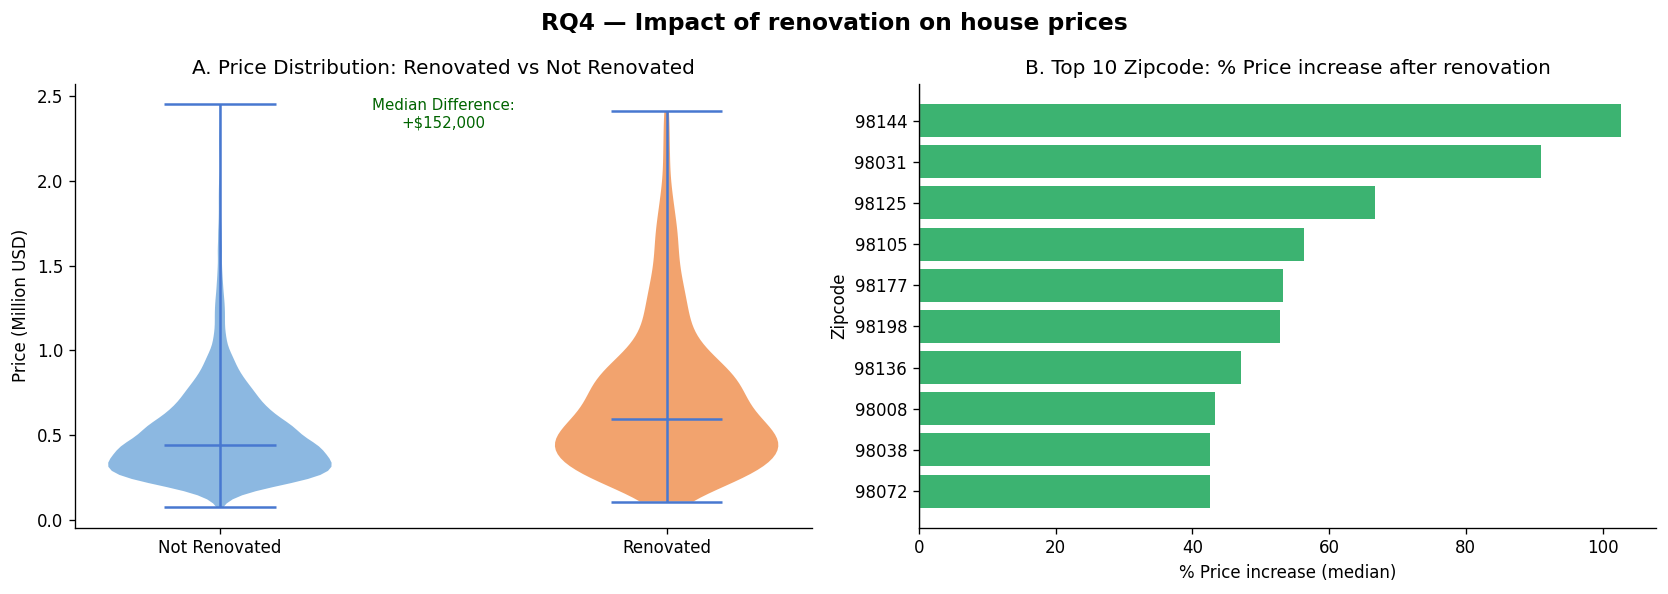

📌 Median price of renovated houses: $0.60M  |  Not renovated: $0.45M
📌 The impact of renovation on price varies significantly across different zipcodes


In [62]:
# RQ4: Renovation impact on price by area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RQ4 — Impact of renovation on house prices', fontsize=14, fontweight='bold')

# A) Overall: violin plot house's price Renovated vs Not Renovated
ax = axes[0]
reno_data    = df[df['is_renovated']==1]['price'] / 1e6
no_reno_data = df[df['is_renovated']==0]['price'] / 1e6
vp = ax.violinplot([no_reno_data, reno_data], positions=[1,2], showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['#5B9BD5','#ED7D31'][i])
    pc.set_alpha(0.7)
ax.set_xticks([1,2])
ax.set_xticklabels(['Not Renovated', 'Renovated'])
ax.set_title('A. Price Distribution: Renovated vs Not Renovated')
ax.set_ylabel('Price (Million USD)')
med1 = no_reno_data.median()
med2 = reno_data.median()
ax.text(1.5, ax.get_ylim()[1]*0.9, f'Median Difference:\n+${(med2-med1)*1e6:,.0f}',
        ha='center', fontsize=9, color='darkgreen')

# B) Top 10 zipcode: % tăng giá khi cải tạo
ax = axes[1]
reno_by_zip = df.groupby(['zipcode','is_renovated'])['price'].median().unstack()
reno_by_zip.columns = ['not_renovated','renovated']
reno_by_zip = reno_by_zip.dropna()
reno_by_zip['pct_increase'] = (reno_by_zip['renovated'] - reno_by_zip['not_renovated']) \
                               / reno_by_zip['not_renovated'] * 100
top10_reno = reno_by_zip.nlargest(10, 'pct_increase')
ax.barh(top10_reno.index.astype(str), top10_reno['pct_increase'], color='mediumseagreen')
ax.set_title('B. Top 10 Zipcode: % Price increase after renovation')
ax.set_xlabel('% Price increase (median)')
ax.set_ylabel('Zipcode')
ax.axvline(0, color='gray', linewidth=0.8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('rq4_renovation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📌 Median price of renovated houses: ${med2:.2f}M  |  Not renovated: ${med1:.2f}M')
print('📌 The impact of renovation on price varies significantly across different zipcodes')


### 📌 RQ5 — How grade and condition jointly affect house prices

>Heatmap of average price by grade × condition

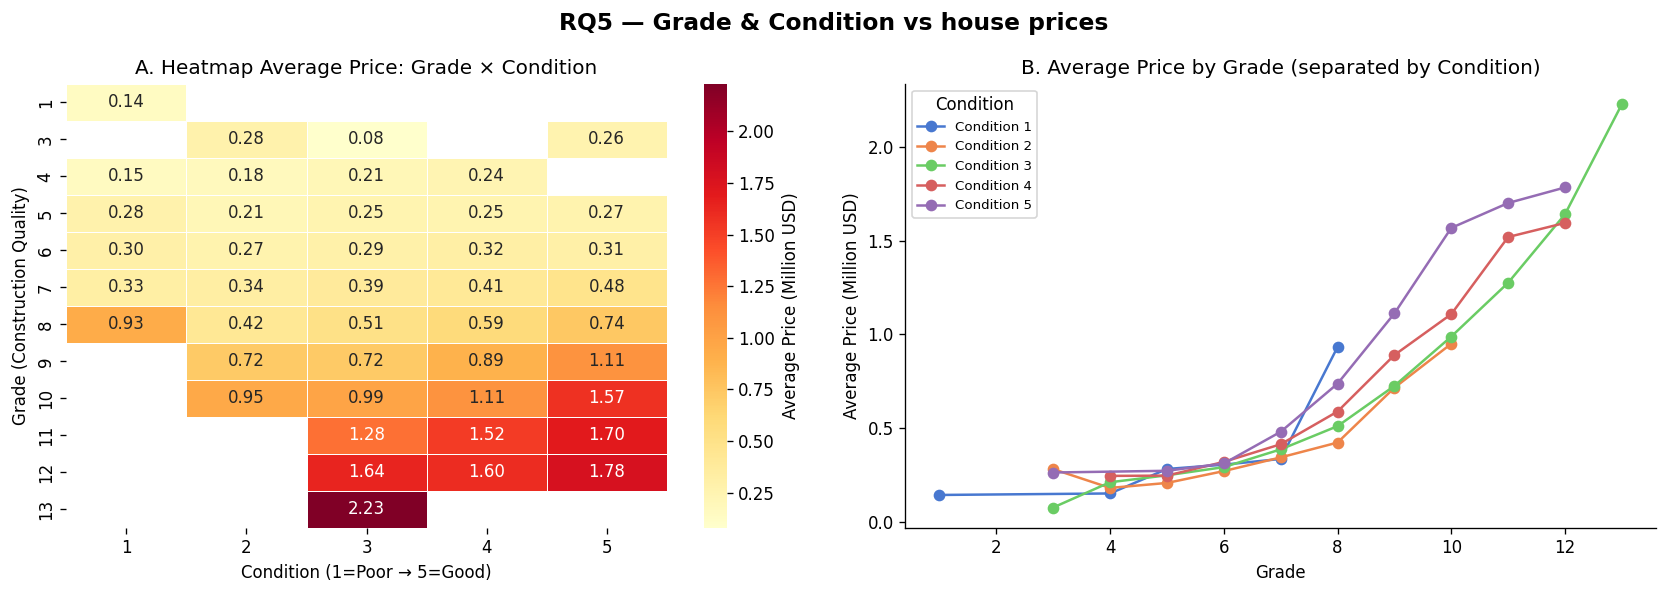

📌 Grade has a stronger impact on price than Condition
📌 Grades 10-13 create a significant price difference regardless of condition


In [63]:
# RQ5: Grade × Condition interaction heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RQ5 — Grade & Condition vs house prices', fontsize=14, fontweight='bold')

# A) Heatmap grade × condition
ax = axes[0]
pivot = df.pivot_table(values='price', index='grade',
                        columns='condition', aggfunc='mean') / 1e6
sns.heatmap(pivot.round(2), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Average Price (Million USD)'})
ax.set_title('A. Heatmap Average Price: Grade × Condition')
ax.set_xlabel('Condition (1=Poor → 5=Good)')
ax.set_ylabel('Grade (Construction Quality)')

# B) Line chart: each condition, average price by grade
ax = axes[1]
for cond in sorted(df['condition'].unique()):
    sub = df[df['condition']==cond].groupby('grade')['price'].mean() / 1e6
    ax.plot(sub.index, sub.values, marker='o', label=f'Condition {int(cond)}', linewidth=1.5)
ax.set_title('B. Average Price by Grade (separated by Condition)')
ax.set_xlabel('Grade')
ax.set_ylabel('Average Price (Million USD)')
ax.legend(title='Condition', fontsize=8)

plt.tight_layout()
plt.savefig('rq5_grade_condition.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Grade has a stronger impact on price than Condition')
print('📌 Grades 10-13 create a significant price difference regardless of condition')


### 📌 RQ6 — Which features contribute most to predicting price?

>Correlation ranking + scatter matrix of top features

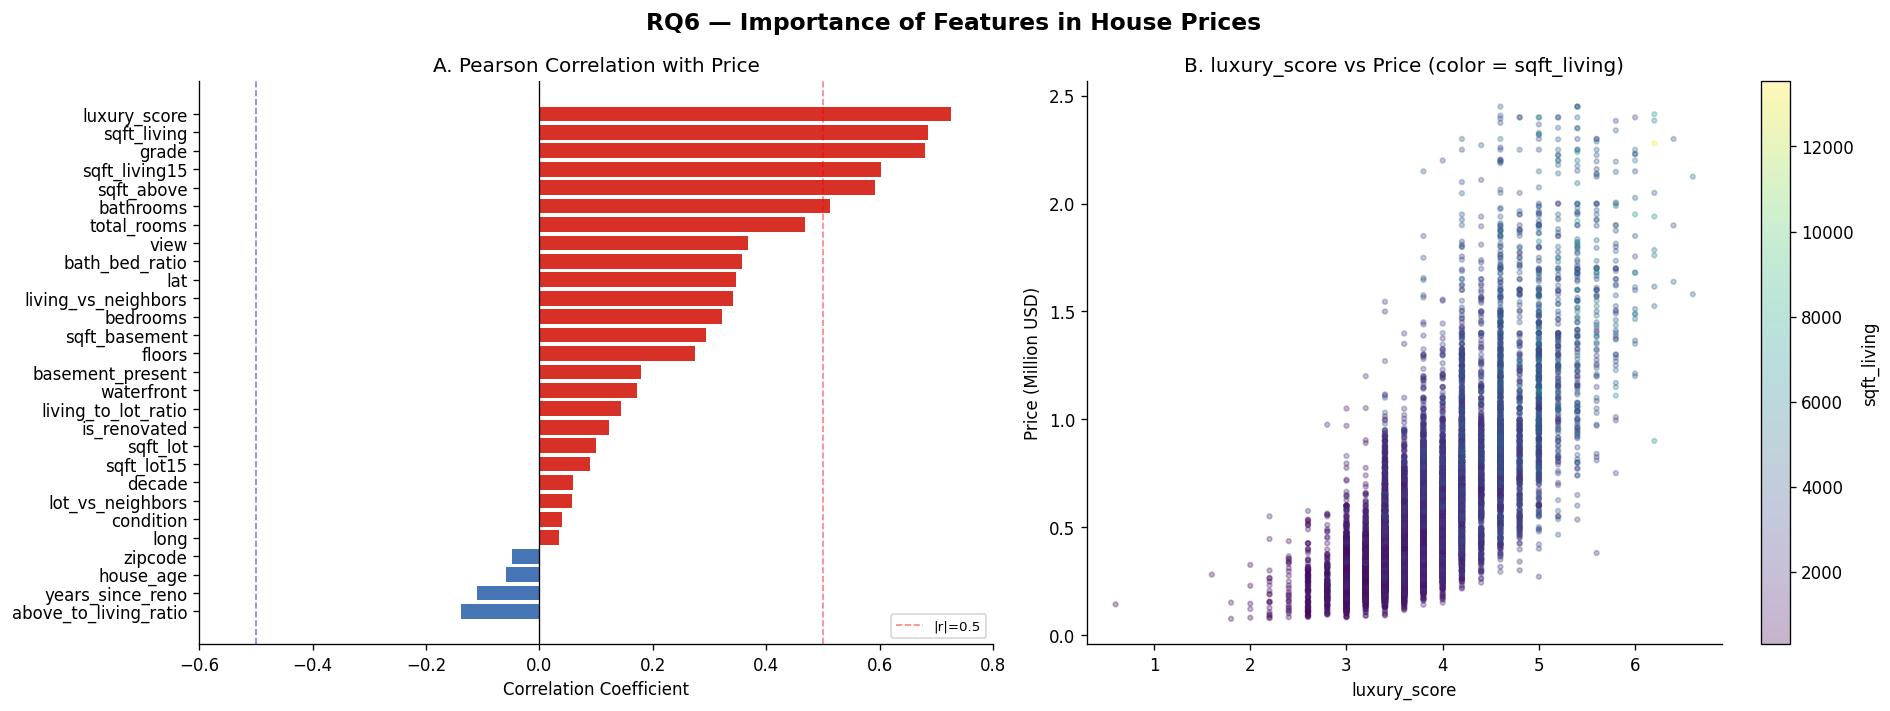

📌 Top 2 feature with strongest correlation to price: ['luxury_score', 'sqft_living']


In [64]:
# RQ6: Feature importance via correlation + pairplot of top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ6 — Importance of Features in House Prices', fontsize=14, fontweight='bold')

# A) Horizontal bar: correlation với price
ax = axes[0]
num_features = df.select_dtypes(include='number').columns.tolist()
num_features = [c for c in num_features if c not in ['price','year_sold','month_sold']]
corr_vals = df[num_features + ['price']].corr()['price'].drop('price').sort_values()

colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_vals.values]
ax.barh(corr_vals.index, corr_vals.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('A. Pearson Correlation with Price')
ax.set_xlabel('Correlation Coefficient')
ax.set_xlim(-0.6, 0.8)
# Mark strong thresholds
ax.axvline(0.5,  color='red',  linewidth=1, linestyle='--', alpha=0.5, label='|r|=0.5')
ax.axvline(-0.5, color='blue', linewidth=1, linestyle='--', alpha=0.5)
ax.legend(fontsize=8)

# B) Scatter: top 2 features vs price
ax = axes[1]
top2 = corr_vals.abs().nlargest(2).index.tolist()
sc = ax.scatter(df[top2[0]], df['price']/1e6,
                c=df[top2[1]], cmap='viridis', alpha=0.3, s=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(top2[1])
ax.set_title(f'B. {top2[0]} vs Price (color = {top2[1]})')
ax.set_xlabel(top2[0])
ax.set_ylabel('Price (Million USD)')

plt.tight_layout()
plt.savefig('rq6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📌 Top 2 feature with strongest correlation to price: {top2}')


## 6. Conclusion & Future Work
### ✅ What has been accomplished
| Step | Content |
|------|----------|
| Data Cleaning | Handled datetime, created new features, removed outliers |
| data_pipeline | Winsorization, KNN imputation, automatic feature selection |
| SQL Analysis | 7 queries from basic to advanced analysis |
| EDA Python | Distribution analysis, correlation, boxplots, scatter plots |
| Visualization | Dashboard, heatmaps, geographic maps |
---
### 🔍 Key Findings
- **sqft_living** and **grade** are the two most important features affecting price (r ≈ 0.70 & 0.67)
- **Waterfront** significantly increases average house price (~2x higher)
- Price distribution is right-skewed → using **log(price)** is recommended for modeling
- Months **April–June** show the highest prices and transaction volume (spring season)
---
### 🚀 Future Work
'''
Phase 1 (Completed) → Data Cleaning + SQL + EDA + Visualization
Phase 2 → Feature Engineering (new variables, categorical encoding)
Phase 3 → Machine Learning (Linear Regression → Random Forest → XGBoost)
Phase 4 → Model Evaluation (RMSE, R², Cross-validation)
Phase 5 → Deployment (Streamlit house price prediction app)
'''
---
### 📚 References
- Dataset: King County House Sales — Kaggle  
- Pandas documentation: https://pandas.pydata.org/docs/  
- Seaborn gallery: https://seaborn.pydata.org/examples/index.html